In [6]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
%cd "/content/drive/MyDrive/Colab Notebooks/LLM Project"

/content/drive/MyDrive/Colab Notebooks/LLM Project


In [3]:
!pip install pandas numpy tqdm rapidfuzz sentence-transformers pyarrow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
 

In [4]:
!pip install -U rapidfuzz


In [ ]:
#Product → sector mapping
#TESTING PRODUCTS FROM INDEX 10,001 TO 20,000


# ================================
#  Imports
# ================================
import re, gc
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
from rapidfuzz import process as fuzzprocess, fuzz as fuzzscore
from sentence_transformers import SentenceTransformer, util
import torch

# ================================
#  CONFIG
# ================================
TOPK_FUZZY = 8
TOPK_FINAL = 3
SEMANTIC_WEIGHT = 0.7
FUZZY_WEIGHT = 0.3
BATCH_SIZE_ENCODE = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ST_MODEL_NAME = "all-mpnet-base-v2"  # good balance speed/accuracy

# Paths — change these for your files
PRODUCTS_FILE = Path("off_translated.parquet")    # your product parquet file
SECTORS_FILE  = Path("Cleaned_Sectors.csv")       # your sectors CSV file
MAP_CACHE     = Path("product_sector_mapping_cache.parquet")
MAP_RESULTS   = Path("product_mapping_10001_20000.parquet")

# ================================
#  Helpers
# ================================
def normalize_text(s: str) -> str:
    """Lowercase and clean text."""
    if not isinstance(s, str):
        return ""
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[\u0000-\u001f]", " ", s)
    return s

def parallel_fuzzy_search(products, sector_names, topk=TOPK_FUZZY):
    """Parallel fuzzy matching."""
    def match_one(name):
        return name, fuzzprocess.extract(name, sector_names, scorer=fuzzscore.WRatio, limit=topk)
    results = {}
    with ThreadPoolExecutor(max_workers=None) as executor:
        for name, matches in tqdm(executor.map(match_one, products),
                                  total=len(products), desc="Step 1/3: Fuzzy shortlist (parallel)"):
            results[name] = [(sec, score) for sec, score, _ in matches]
    return results

# ================================
#  Main Mapping Function
# ================================
def map_products_to_sectors(off_df, sectors_df, start_idx=10001, end_idx=20000, force_recompute=False):
    off_df = off_df.iloc[start_idx:end_idx].copy()
    off_df["text_en"] = off_df["text_en"].map(normalize_text)

    sectors_df = sectors_df.copy()
    sectors_df["sector_name"] = sectors_df["sector_name"].map(normalize_text)

    product_all = off_df["text_en"].astype(str).tolist()
    sector_names = sectors_df["sector_name"].astype(str).tolist()
    uniq_products = pd.Index(product_all).unique().tolist()

    # Load cache
    cache = {}
    if MAP_CACHE.exists() and not force_recompute:
        c = pd.read_parquet(MAP_CACHE)
        cache = {(r.product_text, r.sector_name): (r.semantic_score, r.fuzzy_score) for r in c.itertuples()}
        print(f"[cache] Loaded {len(cache):,} entries")

    # Step 0 — Encode sector embeddings
    print("[emb] Encoding sector embeddings...")
    st_model = SentenceTransformer(ST_MODEL_NAME, device=DEVICE)
    sector_emb = st_model.encode(sector_names, convert_to_tensor=True, show_progress_bar=True)

    # Step 1 — Parallel fuzzy
    fuzzy_dict = parallel_fuzzy_search(uniq_products, sector_names, topk=TOPK_FUZZY)
    gc.collect(); torch.cuda.empty_cache()

    # Step 2 — Product embeddings (batched)
    print("[emb] Encoding product embeddings in batches...")
    prod_embeds = {}
    for i in tqdm(range(0, len(uniq_products), BATCH_SIZE_ENCODE), desc="Step 2/3: Product embedding batches"):
        batch = uniq_products[i:i+BATCH_SIZE_ENCODE]
        embs = st_model.encode(batch, convert_to_tensor=True, show_progress_bar=False)
        for j, name in enumerate(batch):
            prod_embeds[name] = embs[j]
        gc.collect(); torch.cuda.empty_cache()

    # Step 3 — Combine fuzzy + semantic
    print("[rank] Combining scores...")
    results = []
    for name in tqdm(uniq_products, desc="Step 3/3: Ranking"):
        # Use cache if available
        cached_entries = [(sec, sc[0], sc[1]) for (prod, sec), sc in cache.items() if prod == name]
        if cached_entries:
            for sec, sem_sc, fuzz_sc in cached_entries:
                final_sc = SEMANTIC_WEIGHT * sem_sc + FUZZY_WEIGHT * (fuzz_sc / 100)
                results.append((name, sec, sem_sc, fuzz_sc, final_sc))
            continue

        fuzzy_matches = fuzzy_dict.get(name, [])
        if not fuzzy_matches:
            continue

        short_sectors = [sec for sec, _ in fuzzy_matches]
        short_scores = {sec: score for sec, score in fuzzy_matches}

        prod_vec = prod_embeds[name]
        short_embs = st_model.encode(short_sectors, convert_to_tensor=True, show_progress_bar=False)
        sem_scores = util.cos_sim(prod_vec, short_embs)[0].cpu().numpy()

        scored = []
        for sec, sem_score in zip(short_sectors, sem_scores):
            fuzz_score_val = short_scores[sec]
            final_score = SEMANTIC_WEIGHT * sem_score + FUZZY_WEIGHT * (fuzz_score_val / 100)
            scored.append((sec, sem_score, fuzz_score_val, final_score))

        scored_sorted = sorted(scored, key=lambda x: (x[3], x[1]), reverse=True)[:TOPK_FINAL]
        for sec, sem_sc, fuzz_sc, final_sc in scored_sorted:
            results.append((name, sec, sem_sc, fuzz_sc, final_sc))
            cache[(name, sec)] = (float(sem_sc), fuzz_sc)

    gc.collect(); torch.cuda.empty_cache()

    # Save cache
    cache_df = pd.DataFrame(
        [(prod, sec, sem, fuzz) for (prod, sec), (sem, fuzz) in cache.items()],
        columns=["product_text", "sector_name", "semantic_score", "fuzzy_score"]
    )
    cache_df.to_parquet(MAP_CACHE, engine="pyarrow", compression="snappy")
    print(f"[cache] Saved to {MAP_CACHE}")

    # Expand results to all rows
    rows_out = []
    prod_to_results = {}
    for prod, sec, sem, fuzz, final in results:
        prod_to_results.setdefault(prod, []).append((sec, sem, fuzz, final))

    for idx, prod in enumerate(product_all):
        for sec, sem_sc, fuzz_sc, final_sc in prod_to_results.get(prod, []):
            rows_out.append((idx + start_idx, prod, sec, sem_sc, fuzz_sc, final_sc))

    out = pd.DataFrame(rows_out, columns=["off_index","product_text","sector_name","semantic_score","fuzzy_score","final_score"])
    out.sort_values(["off_index","final_score","semantic_score"], ascending=[True, False, False], inplace=True)
    out.to_parquet(MAP_RESULTS, engine="pyarrow", compression="snappy")
    print(f"[results] Saved mapping to {MAP_RESULTS}")

    return out.reset_index(drop=True)

# ================================
#  Load Data & Run Mapping
# ================================
print("Loading product and sector files...")
products_df = pd.read_parquet(PRODUCTS_FILE)
sectors_df = pd.read_csv(SECTORS_FILE)
sectors_df.rename(columns={"CPC_description": "sector_name"}, inplace=True)

mapping_df = map_products_to_sectors(products_df, sectors_df, start_idx=10001, end_idx=20000, force_recompute=False)
mapping_df.head(20)


Loading product and sector files...
[emb] Encoding sector embeddings...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Step 1/3: Fuzzy shortlist (parallel):   0%|          | 0/9593 [00:00<?, ?it/s]

[emb] Encoding product embeddings in batches...


Step 2/3: Product embedding batches:   0%|          | 0/19 [00:00<?, ?it/s]

[rank] Combining scores...


Step 3/3: Ranking:   0%|          | 0/9593 [00:00<?, ?it/s]

[cache] Saved to product_sector_mapping_cache.parquet
[results] Saved mapping to product_mapping_10001_20000.parquet


,off_index,product_text,sector_name,semantic_score,fuzzy_score,final_score
0,10001,coarse sea salt big win sea salt.,sea and coastal water transport,0.341729,50.666667,0.391210
1,10001,coarse sea salt big win sea salt.,casting of metals,0.184210,47.647059,0.271888
2,10001,coarse sea salt big win sea salt.,"manure treatment (biogas), storage and land ap...",0.115342,43.548387,0.211385
3,10002,"garlic salt big win salt, dehydrated garlic, s...",processed rice,0.286373,45.000000,0.335461
4,10002,"garlic salt big win salt, dehydrated garlic, s...","plastics, basic",0.189955,48.000000,0.276969
5,10002,"garlic salt big win salt, dehydrated garlic, s...",processing vegetable oils and fats,0.213472,42.000000,0.275431
6,10003,"california seedless raisins big win, rite aid ...",cultivation of cereal grains nec,0.293735,48.000000,0.349614
7,10003,"california seedless raisins big win, rite aid ...",cultivation of oil seeds,0.244709,51.428571,0.325582
8,10003,"california seedless raisins big win, rite aid ...",cattle farming,0.114458,49.090909,0.227394
9,10004,"sparkling water beverage, kiwi strawberry big ...","collection, purification and distribution of w...",0.190095,85.500000,0.389566


/tmp/ipython-input-1984940958.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_sectors.index, x=top_sectors.values, palette="viridis")


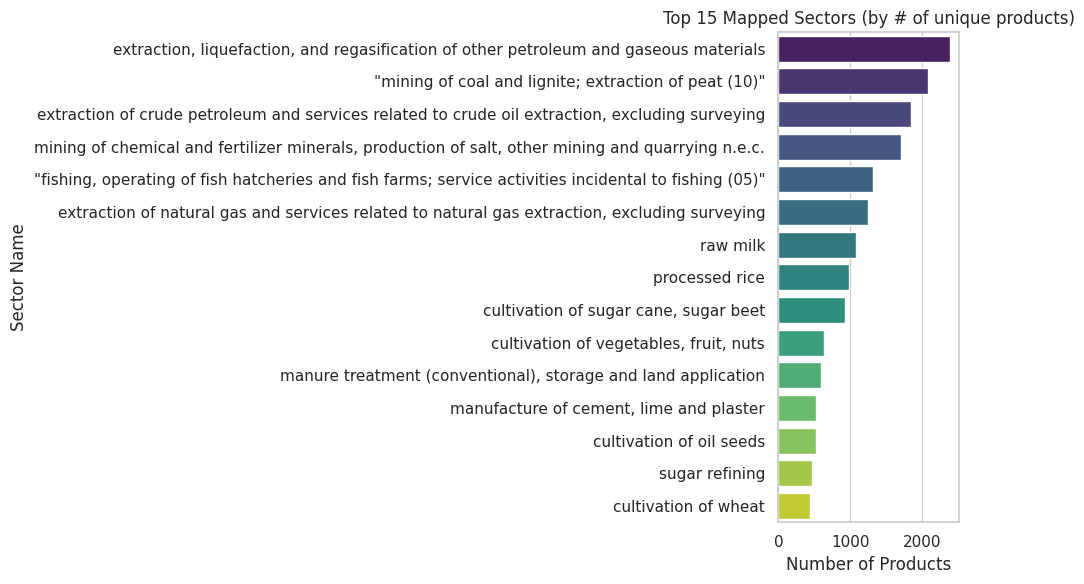

In [ ]:
# ================================
#  Visualization
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#  Top sectors by product count
top_sectors = mapping_df.groupby("sector_name")["product_text"].nunique().sort_values(ascending=False).head(15)
plt.figure()
sns.barplot(y=top_sectors.index, x=top_sectors.values, palette="viridis")
plt.title("Top 15 Mapped Sectors (by # of unique products)")
plt.xlabel("Number of Products")
plt.ylabel("Sector Name")
plt.tight_layout()
plt.show()



[UMAP] Recomputing product embeddings for visualization...


Batches:   0%|          | 0/300 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


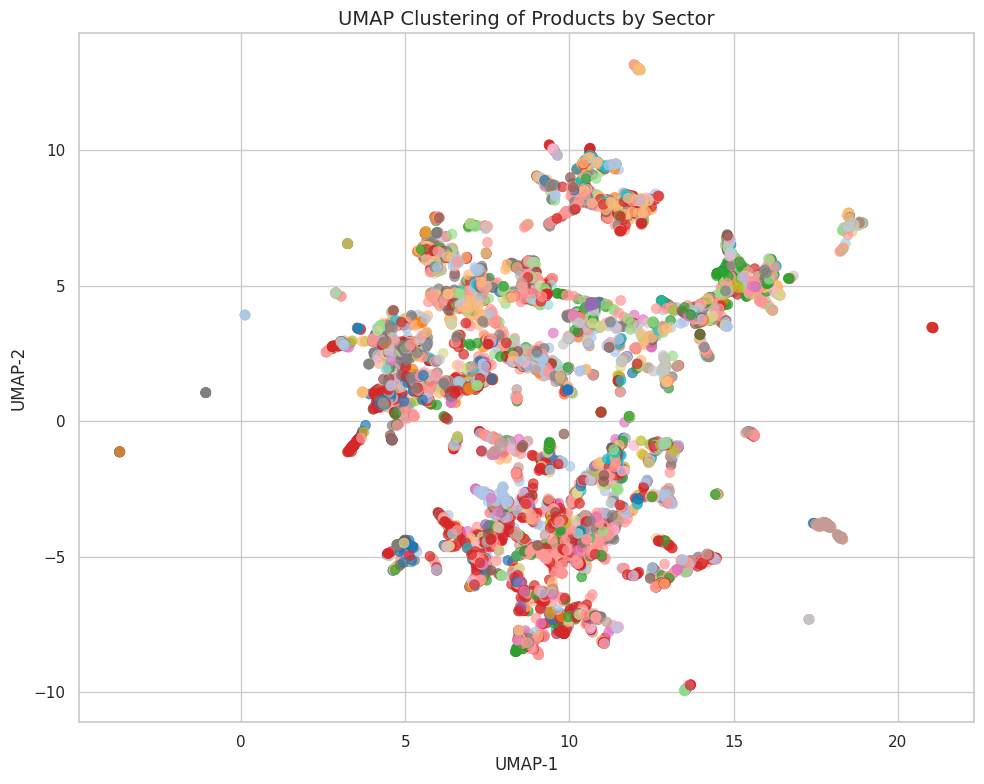

In [ ]:
!pip install umap-learn

import umap.umap_ as umap

# Prepare data: pick unique products + their embeddings + sector
unique_mappings = mapping_df.drop_duplicates(subset=["product_text"])[["product_text", "sector_name"]]

print("[UMAP] Recomputing product embeddings for visualization...")
st_model = SentenceTransformer(ST_MODEL_NAME, device=DEVICE)
prod_embs = st_model.encode(unique_mappings["product_text"].tolist(), convert_to_tensor=False, show_progress_bar=True)

# Reduce to 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
embedding_2d = reducer.fit_transform(prod_embs)

# Add coordinates back to dataframe
unique_mappings["x"] = embedding_2d[:, 0]
unique_mappings["y"] = embedding_2d[:, 1]

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=unique_mappings,
    x="x", y="y",
    hue="sector_name",
    palette="tab20",
    s=50,
    alpha=0.7,
    edgecolor=None,
    legend=False  # Set True if you want the full legend
)
plt.title("UMAP Clustering of Products by Sector", fontsize=14)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


In [ ]:
#TESTING PRODUCTS FROM INDEX 20,001 TO 50,000
# ================================
#  Imports
# ================================
import re, gc
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
from rapidfuzz import process as fuzzprocess, fuzz as fuzzscore
from sentence_transformers import SentenceTransformer, util
import torch

# ================================
#  CONFIG
# ================================
TOPK_FUZZY = 8
TOPK_FINAL = 3
SEMANTIC_WEIGHT = 0.7
FUZZY_WEIGHT = 0.3
BATCH_SIZE_ENCODE = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ST_MODEL_NAME = "all-mpnet-base-v2"  # good balance speed/accuracy

# Paths — change these for your files
PRODUCTS_FILE = Path("off_translated.parquet")    # your product parquet file
SECTORS_FILE  = Path("Cleaned_Sectors.csv")       # your sectors CSV file
MAP_CACHE     = Path("product_sector_mapping_cache2.parquet")
MAP_RESULTS   = Path("product_mapping_20001_50000.parquet")

# ================================
#  Helpers
# ================================
def normalize_text(s: str) -> str:
    """Lowercase and clean text."""
    if not isinstance(s, str):
        return ""
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[\u0000-\u001f]", " ", s)
    return s

def parallel_fuzzy_search(products, sector_names, topk=TOPK_FUZZY):
    """Parallel fuzzy matching."""
    def match_one(name):
        return name, fuzzprocess.extract(name, sector_names, scorer=fuzzscore.WRatio, limit=topk)
    results = {}
    with ThreadPoolExecutor(max_workers=None) as executor:
        for name, matches in tqdm(executor.map(match_one, products),
                                  total=len(products), desc="Step 1/3: Fuzzy shortlist (parallel)"):
            results[name] = [(sec, score) for sec, score, _ in matches]
    return results

# ================================
#  Main Mapping Function
# ================================
def map_products_to_sectors(off_df, sectors_df, start_idx=20001, end_idx=50000, force_recompute=False):
    off_df = off_df.iloc[start_idx:end_idx].copy()
    off_df["text_en"] = off_df["text_en"].map(normalize_text)

    sectors_df = sectors_df.copy()
    sectors_df["sector_name"] = sectors_df["sector_name"].map(normalize_text)

    product_all = off_df["text_en"].astype(str).tolist()
    sector_names = sectors_df["sector_name"].astype(str).tolist()
    uniq_products = pd.Index(product_all).unique().tolist()

    # Load cache
    cache = {}
    if MAP_CACHE.exists() and not force_recompute:
        c = pd.read_parquet(MAP_CACHE)
        cache = {(r.product_text, r.sector_name): (r.semantic_score, r.fuzzy_score) for r in c.itertuples()}
        print(f"[cache] Loaded {len(cache):,} entries")

    # Step 0 — Encode sector embeddings
    print("[emb] Encoding sector embeddings...")
    st_model = SentenceTransformer(ST_MODEL_NAME, device=DEVICE)
    sector_emb = st_model.encode(sector_names, convert_to_tensor=True, show_progress_bar=True)

    # Step 1 — Parallel fuzzy
    fuzzy_dict = parallel_fuzzy_search(uniq_products, sector_names, topk=TOPK_FUZZY)
    gc.collect(); torch.cuda.empty_cache()

    # Step 2 — Product embeddings (batched)
    print("[emb] Encoding product embeddings in batches...")
    prod_embeds = {}
    for i in tqdm(range(0, len(uniq_products), BATCH_SIZE_ENCODE), desc="Step 2/3: Product embedding batches"):
        batch = uniq_products[i:i+BATCH_SIZE_ENCODE]
        embs = st_model.encode(batch, convert_to_tensor=True, show_progress_bar=False)
        for j, name in enumerate(batch):
            prod_embeds[name] = embs[j]
        gc.collect(); torch.cuda.empty_cache()

    # Step 3 — Combine fuzzy + semantic
    print("[rank] Combining scores...")
    results = []
    for name in tqdm(uniq_products, desc="Step 3/3: Ranking"):
        # Use cache if available
        cached_entries = [(sec, sc[0], sc[1]) for (prod, sec), sc in cache.items() if prod == name]
        if cached_entries:
            for sec, sem_sc, fuzz_sc in cached_entries:
                final_sc = SEMANTIC_WEIGHT * sem_sc + FUZZY_WEIGHT * (fuzz_sc / 100)
                results.append((name, sec, sem_sc, fuzz_sc, final_sc))
            continue

        fuzzy_matches = fuzzy_dict.get(name, [])
        if not fuzzy_matches:
            continue

        short_sectors = [sec for sec, _ in fuzzy_matches]
        short_scores = {sec: score for sec, score in fuzzy_matches}

        prod_vec = prod_embeds[name]
        short_embs = st_model.encode(short_sectors, convert_to_tensor=True, show_progress_bar=False)
        sem_scores = util.cos_sim(prod_vec, short_embs)[0].cpu().numpy()

        scored = []
        for sec, sem_score in zip(short_sectors, sem_scores):
            fuzz_score_val = short_scores[sec]
            final_score = SEMANTIC_WEIGHT * sem_score + FUZZY_WEIGHT * (fuzz_score_val / 100)
            scored.append((sec, sem_score, fuzz_score_val, final_score))

        scored_sorted = sorted(scored, key=lambda x: (x[3], x[1]), reverse=True)[:TOPK_FINAL]
        for sec, sem_sc, fuzz_sc, final_sc in scored_sorted:
            results.append((name, sec, sem_sc, fuzz_sc, final_sc))
            cache[(name, sec)] = (float(sem_sc), fuzz_sc)

    gc.collect(); torch.cuda.empty_cache()

    # Save cache
    cache_df = pd.DataFrame(
        [(prod, sec, sem, fuzz) for (prod, sec), (sem, fuzz) in cache.items()],
        columns=["product_text", "sector_name", "semantic_score", "fuzzy_score"]
    )
    cache_df.to_parquet(MAP_CACHE, engine="pyarrow", compression="snappy")
    print(f"[cache] Saved to {MAP_CACHE}")

    # Expand results to all rows
    rows_out = []
    prod_to_results = {}
    for prod, sec, sem, fuzz, final in results:
        prod_to_results.setdefault(prod, []).append((sec, sem, fuzz, final))

    for idx, prod in enumerate(product_all):
        for sec, sem_sc, fuzz_sc, final_sc in prod_to_results.get(prod, []):
            rows_out.append((idx + start_idx, prod, sec, sem_sc, fuzz_sc, final_sc))

    out = pd.DataFrame(rows_out, columns=["off_index","product_text","sector_name","semantic_score","fuzzy_score","final_score"])
    out.sort_values(["off_index","final_score","semantic_score"], ascending=[True, False, False], inplace=True)
    out.to_parquet(MAP_RESULTS, engine="pyarrow", compression="snappy")
    print(f"[results] Saved mapping to {MAP_RESULTS}")

    return out.reset_index(drop=True)

# ================================
#  Load Data & Run Mapping
# ================================
print("Loading product and sector files...")
products_df = pd.read_parquet(PRODUCTS_FILE)
sectors_df = pd.read_csv(SECTORS_FILE)
sectors_df.rename(columns={"CPC_description": "sector_name"}, inplace=True)

mapping_df = map_products_to_sectors(products_df, sectors_df, start_idx=20001, end_idx=50000, force_recompute=False)
mapping_df.head(20)


Loading product and sector files...
[cache] Loaded 28,779 entries
[emb] Encoding sector embeddings...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Step 1/3: Fuzzy shortlist (parallel):   0%|          | 0/28748 [00:00<?, ?it/s]

[emb] Encoding product embeddings in batches...


Step 2/3: Product embedding batches:   0%|          | 0/57 [00:00<?, ?it/s]

[rank] Combining scores...


Step 3/3: Ranking:   0%|          | 0/28748 [00:00<?, ?it/s]

[cache] Saved to product_sector_mapping_cache.parquet
[results] Saved mapping to product_mapping_10001_20000.parquet


,off_index,product_text,sector_name,semantic_score,fuzzy_score,final_score
0,20001,pancake mix lehi roller mills co. inc. bleache...,mining of nickel ores and concentrates,0.219168,45.000000,0.288418
1,20001,pancake mix lehi roller mills co. inc. bleache...,"mining of lead, zinc and tin ores and concentr...",0.221492,43.200000,0.284644
2,20001,pancake mix lehi roller mills co. inc. bleache...,extraction of natural gas and services related...,0.036625,85.500000,0.282137
3,20002,"lehi roller mills, cookie mix, pumpkin chocola...",pulp,0.249645,45.000000,0.309752
4,20002,"lehi roller mills, cookie mix, pumpkin chocola...",mining of other non-ferrous metal ores and con...,0.230681,40.909091,0.284204
5,20002,"lehi roller mills, cookie mix, pumpkin chocola...","mining of lead, zinc and tin ores and concentr...",0.210198,43.200000,0.276739
6,20003,"pcc, organic lowfat milk puget consumers co-op...",raw milk,0.401781,57.000000,0.452247
7,20003,"pcc, organic lowfat milk puget consumers co-op...","plastics, basic",0.274379,51.300000,0.345966
8,20003,"pcc, organic lowfat milk puget consumers co-op...",cattle farming,0.187775,51.428571,0.285729
9,20004,"pcc, organic 2% reduced fat milk puget consume...",raw milk,0.390369,57.000000,0.444258


In [19]:
#LCA data (Clark et al. + FAOSTAT): align to CO₂/Land/Water, unit harmonization

import re, gc
import numpy as np
import pandas as pd
from pathlib import Path
from rapidfuzz import process as fuzzprocess, fuzz as fuzzscore

# ----------------------
# Paths
# ----------------------

IN_MAP   = "product_mapping_10001_20000.parquet"  # OFF→sector mapping
IN_LCA   = "Environmental impacts of food (LCA).csv"    # Clark LCA
IN_FAO   = "FAOSTAT_data.csv"                     # FAO prices

OUT_DIR = Path("harmonized_micro")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PROD = "all_products_off_lca_x_price.csv"
OUT_SECT = "all_products_micro_extension_sector_level.csv"

# ----------------------
# Helpers
# ----------------------
def norm_text(s):
    if not isinstance(s, str): return ""
    return re.sub(r"\s+", " ", s.strip().lower())

def to_usd_per_kg(unit_str, value):
    if pd.isna(value): return np.nan
    u = str(unit_str).lower().strip()
    val = float(value)
    if "per 100g" in u: return val * 10
    if re.search(r"/\s*kg\b", u): return val
    if re.search(r"(ton|tonne|t)\b", u): return val / 1000
    if re.search(r"mt\b", u): return val / 1000
    return np.nan

def wmean(values, weights):
    v = np.asarray(values, dtype=float)
    w = np.asarray(weights, dtype=float)
    m = ~np.isnan(v) & ~np.isnan(w) & (w > 0)
    return float(np.average(v[m], weights=w[m])) if np.any(m) else np.nan

# ----------------------
# Load mapping (product→sector)
# ----------------------
map_df = pd.read_parquet(IN_MAP)
map_df["product_text"] = map_df["product_text"].astype(str).map(norm_text)
map_df["sector_name"]  = map_df["sector_name"].astype(str).map(norm_text)

# ----------------------
# Load Clark LCA
# ----------------------
lca = pd.read_csv(IN_LCA)
lca["lca_item"] = lca.iloc[:, 0].astype(str).map(norm_text)
for col in ["co2_per_kg", "land_per_kg", "water_per_kg"]:
    if col in lca.columns:
        lca[col] = pd.to_numeric(lca[col], errors="coerce")

# ----------------------
# Fuzzy match product_text → Clark LCA
# ----------------------
lca_items = lca["lca_item"].tolist()
def fuzzy_match_lca(name):
    match = fuzzprocess.extractOne(name, lca_items, scorer=fuzzscore.WRatio)
    return match[0] if match else None

map_df["lca_item"] = map_df["product_text"].map(fuzzy_match_lca)
prod = map_df.merge(lca, on="lca_item", how="left")

gc.collect()
# ----------------------
# Load FAOSTAT prices
# ----------------------
fao = pd.read_csv(IN_FAO)
fao["Value"] = pd.to_numeric(fao["Value"], errors="coerce")
fao["faostat_item"] = fao["Item"].map(norm_text)
fao["usd_per_kg"] = [to_usd_per_kg(u, v) for u, v in zip(fao["Unit"], fao["Value"])]
price_df = fao.groupby("faostat_item", as_index=False)["usd_per_kg"].median()

# ----------------------
# Fuzzy match LCA item → FAOSTAT
# ----------------------
faostat_items = price_df["faostat_item"].tolist()
def fuzzy_match_fao(name):
    match = fuzzprocess.extractOne(name, faostat_items, scorer=fuzzscore.WRatio)
    return match[0] if match else None

prod["faostat_item"] = prod["lca_item"].map(fuzzy_match_fao)
prod = prod.merge(price_df, on="faostat_item", how="left")

gc.collect()
# ----------------------
# Per USD intensities
# ----------------------
for base_col in ["co2_per_kg", "land_per_kg", "water_per_kg"]:
    if base_col in prod.columns:
        prod[base_col.replace("_per_kg", "_per_usd")] = prod[base_col] / prod["usd_per_kg"]

# ----------------------
# Save product-level table
# ----------------------
prod.to_csv(OUT_PROD, index=False)
print(f" Saved product-level → {OUT_PROD}")


# ----------------------
# Aggregate to sector-level
# ----------------------
# ------------------------
# SECTOR-LEVEL aggregation (fixed get() length)
# ------------------------
agg_rows = []
for sec, g in prod.groupby("sector_name", sort=False):
    w = pd.to_numeric(g["final_score"], errors="coerce").fillna(0).clip(0, 1).astype(float).values

    def get(col):
        if col in g.columns:
            return pd.to_numeric(g[col], errors="coerce").values
        else:
            return np.full(len(w), np.nan, dtype=float)  # match length of weights

    agg_rows.append((
        sec,
        wmean(get("co2_per_kg"), w),
        wmean(get("land_per_kg"), w),
        wmean(get("water_per_kg"), w),
        np.nanmedian(get("usd_per_kg")),
        wmean(get("co2_per_usd"), w),
        wmean(get("land_per_usd"), w),
        wmean(get("water_per_usd"), w),
        int(pd.Series(g["product_text"]).nunique()),
        int(np.isfinite(get("usd_per_kg")).sum())
    ))

sector = pd.DataFrame(agg_rows, columns=[
    "sector_name",
    "co2_per_kg_mean", "land_per_kg_mean", "water_per_kg_mean",
    "usd_per_kg_median",
    "co2_per_usd_mean", "land_per_usd_mean", "water_per_usd_mean",
    "n_products", "n_priced_items"
]).sort_values(["n_products", "n_priced_items"], ascending=[False, False]).reset_index(drop=True)

sector.to_csv(OUT_SECT, index=False)
print(f" Saved sector-level → {OUT_SECT}")

gc.collect()

from IPython.display import display

# Show product-level first 20 rows as table
print("\n— Product-level (first 20) —")
display(prod.head(20))

# Show sector-level first 20 rows as table
print("\n— Sector-level (first 20) —")
display(sector.head(20))






 Saved product-level → all_products_off_lca_x_price.csv


/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(get("usd_per_kg")),
/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(get("usd_per_kg")),
/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(get("usd_per_kg")),
/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(get("usd_per_kg")),
/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(get("usd_per_kg")),
/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(get("usd_per_kg")),
/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(get("usd_per_kg")),
/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(get("usd_per_kg")),
/tmp/ipython-input-4240403436.py:129: RuntimeWarning: All-NaN slice encountered


 Saved sector-level → all_products_micro_extension_sector_level.csv

— Product-level (first 20) —


,off_index,product_text,sector_name,semantic_score,fuzzy_score,final_score,lca_item,Entity,Year,ghg_kg,...,water_kg,water_1000kcal,water_100gprotein,water_100gfat,biodiversity_kg,biodiversity_1000kcal,biodiversity_100gprotein,biodiversity_100gfat,faostat_item,usd_per_kg
0,10001,coarse sea salt big win sea salt.,sea and coastal water transport,0.341729,50.666667,0.391210,caesar salad,Caesar salad,2022,2.079189,...,305.766336,222.983482,953.066701,281.748128,88.859689,65.026411,283.141717,82.204371,canary seed,NaN
1,10001,coarse sea salt big win sea salt.,casting of metals,0.184210,47.647059,0.271888,caesar salad,Caesar salad,2022,2.079189,...,305.766336,222.983482,953.066701,281.748128,88.859689,65.026411,283.141717,82.204371,canary seed,NaN
2,10001,coarse sea salt big win sea salt.,"manure treatment (biogas), storage and land ap...",0.115342,43.548387,0.211385,caesar salad,Caesar salad,2022,2.079189,...,305.766336,222.983482,953.066701,281.748128,88.859689,65.026411,283.141717,82.204371,canary seed,NaN
3,10002,"garlic salt big win salt, dehydrated garlic, s...",processed rice,0.286373,45.000000,0.335461,chicken wings,Chicken wings,2022,9.583456,...,631.833951,306.878959,335.462074,470.117031,235.576108,114.315311,125.605543,171.639264,figs,NaN
4,10002,"garlic salt big win salt, dehydrated garlic, s...","plastics, basic",0.189955,48.000000,0.276969,chicken wings,Chicken wings,2022,9.583456,...,631.833951,306.878959,335.462074,470.117031,235.576108,114.315311,125.605543,171.639264,figs,NaN
5,10002,"garlic salt big win salt, dehydrated garlic, s...",processing vegetable oils and fats,0.213472,42.000000,0.275431,chicken wings,Chicken wings,2022,9.583456,...,631.833951,306.878959,335.462074,470.117031,235.576108,114.315311,125.605543,171.639264,figs,NaN
6,10003,"california seedless raisins big win, rite aid ...",cultivation of cereal grains nec,0.293735,48.000000,0.349614,chia seeds,Chia seeds,2022,1.220554,...,210.903545,58.986739,108.155664,79.287047,104.987747,29.363588,53.839870,39.469078,castor oil seeds,NaN
7,10003,"california seedless raisins big win, rite aid ...",cultivation of oil seeds,0.244709,51.428571,0.325582,chia seeds,Chia seeds,2022,1.220554,...,210.903545,58.986739,108.155664,79.287047,104.987747,29.363588,53.839870,39.469078,castor oil seeds,NaN
8,10003,"california seedless raisins big win, rite aid ...",cattle farming,0.114458,49.090909,0.227394,chia seeds,Chia seeds,2022,1.220554,...,210.903545,58.986739,108.155664,79.287047,104.987747,29.363588,53.839870,39.469078,castor oil seeds,NaN
9,10004,"sparkling water beverage, kiwi strawberry big ...","collection, purification and distribution of w...",0.190095,85.500000,0.389566,strawberry jam,Strawberry jam,2022,2.596663,...,949.701598,415.744316,20183.207957,61580.810526,80.798645,39.171835,1692.549194,5293.263999,strawberries,NaN



— Sector-level (first 20) —


,sector_name,co2_per_kg_mean,land_per_kg_mean,water_per_kg_mean,usd_per_kg_median,co2_per_usd_mean,land_per_usd_mean,water_per_usd_mean,n_products,n_priced_items
0,"extraction, liquefaction, and regasification o...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2393,0
1,"""mining of coal and lignite; extraction of pea...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2092,0
2,extraction of crude petroleum and services rel...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1843,0
3,"mining of chemical and fertilizer minerals, pr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,1704,0
4,"""fishing, operating of fish hatcheries and fis...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,1315,0
5,extraction of natural gas and services related...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1243,0
6,raw milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1086,0
7,processed rice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,991,0
8,"cultivation of sugar cane, sugar beet",NaN,NaN,NaN,NaN,NaN,NaN,NaN,924,0
9,"cultivation of vegetables, fruit, nuts",NaN,NaN,NaN,NaN,NaN,NaN,NaN,642,0
